# 02 · Baseline y evaluación honesta

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


## Ajuste exclusivo en entrenamiento
Scaler y encoder se ajustan dentro del Pipeline. El umbral 0.25 es ilustrativo.

In [2]:
estimator=pipeline();estimator.fit(train[FEATURES],(train.y=="yes").astype(int))
probability=estimator.predict_proba(validation[FEATURES])[:,1]
result=metrics((validation.y=="yes").astype(int),probability)
display(pd.Series({k:v for k,v in result.items() if k!="confusion_matrix"}))
display(pd.DataFrame(result["confusion_matrix"],index=["real no","real yes"],columns=["pred no","pred yes"]))

n                    9042.000000
prevalence              0.117894
average_precision       0.168429
roc_auc                 0.624764
precision               0.000000
recall                  0.000000
f1                      0.000000
brier                   0.104156
threshold               0.250000
dtype: float64

,pred no,pred yes
real no,7972,4
real yes,1066,0


## Sensibilidad al umbral
Esta exploración usa validación. No seleccionar umbrales con prueba final.

,threshold,precision,recall,f1
0,0.05,0.147544,0.797373,0.249011
1,0.10,0.177349,0.378987,0.241627
2,0.15,0.236994,0.038462,0.066182
3,0.25,0.000000,0.000000,0.000000
4,0.50,0.000000,0.000000,0.000000


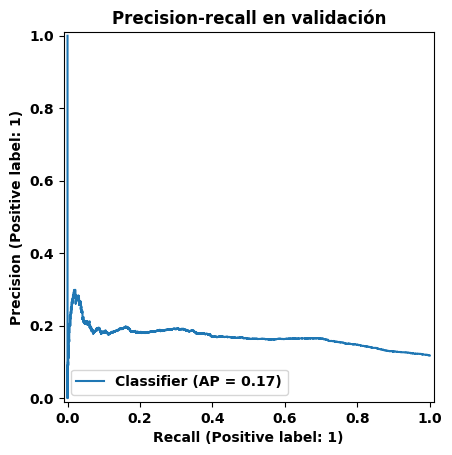

In [3]:
rows=[metrics((validation.y=="yes").astype(int),probability,t) for t in [.05,.1,.15,.25,.5]]
display(pd.DataFrame(rows)[["threshold","precision","recall","f1"]])
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
PrecisionRecallDisplay.from_predictions((validation.y=="yes").astype(int),probability)
plt.title("Precision-recall en validación");plt.show()

## Interpretación
Si recall es cero, no ocultar el resultado. ¿Qué significa para falsos negativos? ¿Qué costos necesitaría para elegir un umbral? Comparar AP con prevalencia.